# **OFDM** 

### ¿Qué es?
OFDM (Multiplexación por División de Frecuencia Ortogonal) es un método de modulación multiportadora digital para transmisión de símbolos. Divide un canal de alta velocidad en múltiples subportadoras de baja velocidad. Estas subportadoras están matemáticamente diseñadas para ser ortogonales, lo que permite que sus espectros se solapen sin interferirse mutuamente, transmitiendo datos en paralelo, mejorando la eficiencia espectral. 

Básicamente, en lugar de enviar los datos en una sola portadora, OFDM divide la señal en muchas señales más pequeñas y las transmite simultáneamente, permitiendo mayor resistencia a la interferencia y a la dispersión en el canal.

Uno de los elementos clave de la implementación de OFDM es el uso de la transformada discreta de Fourier (DFT) y su inversa (IDFT), que permiten una conversión eficaz de la señal entre los dominios de la frecuencia y el tiempo.

### ¿En qué se usa OFDM?
Se utiliza en los sistemas modernos de comunicaciones digitales de banda ancha, especialmente en entornos con multipropagación. Por ejemplo en comunicaciones WiFi, Redes celulares 4G y 5G, Televisión digital terrestre, etc.

---

# Transmisor OFDM

La información que se quiere transmitir es una secuencia de bits.
La agrupación de estos bits forman símbolos, que luego son modulados digitalmente, por ejemplo en modulación **QPSK, QAM16, QAM64, etc**.
Al usar estas modulaciones los símbolos quedan mapeados como números complejos, obteniendo así una secuencia de **símbolos complejos**.

## Símbolos Complejos
Los símbolos complejos resultantes se asignan a las distintas subportadoras en el dominio de la frecuencia. La **IDFT** permite transformar esta representación en frecuencia al dominio temporal para su transmisión física. 

## Señal OFDM en tiempo discreto
Para transmitir los símbolos en paralelo sobre múltiples subportadoras ortogonales, la IDFT genera en el dominio temporal la combinación lineal de exponenciales complejas ortogonales.
Para implementarlo, se generan $N$ muestras discretas que constituyen un símbolo OFDM en el dominio temporal.
Podemos definir $T$ como el periodo de cada símbolo OFDM y $T_s$ como el periodo de muestreo $(T_s=T/N)$.
Con un paso de $t=nT_s$ ($t=nT/N$), la señal OFDM se determina como:

$$
x[n] = \sum_{k=0}^{N-1} X[k] \, e^{j 2\pi \frac{kn}{N}}
$$

Para $n=0,1,2,...,N-1$

Donde:
- $X[k]$ son los símbolos complejos asignados a cada subportadora.
- Cada término exponencial representa una subportadora ortogonal.
- Cada muestra $x[n]$ es una combinación de todas las subportadoras.
- El bloque completo de $N$ muestras forma un **símbolo OFDM**

## Garantía de Ortogonalidad
Si definimos dos vectores complejos $\phi_k$ y $\phi_m$, la ortogonalidad se da cuando al calcular el producto interno entre ellos es igual a 0,  $\langle \phi_k , \phi_m\rangle = 0$.

Por lo tanto cada subportadora es ortogonal entre sí, si se cumple que para:

$$
\langle \phi_k[n] , \phi_m[n]\rangle = \sum_{n=0}^{N-1} e^{j 2\pi \frac{kn}{N}}.e^{-j 2\pi \frac{mn}{N}}= \sum_{n=0}^{N-1}e^{j 2\pi (k-m)\frac{n}{N}} = \ 0 \ para \ k \neq m.
$$

Si definimos $r=e^{j 2\pi \frac{(k-m)}{N}}$, y reemplazamos en la sumatoria, obtenemos una serie geométrica compleja $S$.
$$
S = \sum_{n=0}^{N-1}r^n = \frac{1-r^N }{1-r} \ si \ r \neq 1
$$
Para cumplir con la condición de que $\langle \phi_k[n] , \phi_m[n]\rangle = 0$, $\ r^N$ debe ser 1.
$$
r^N = (e^{j 2\pi \frac{(k-m)}{N}})^N = e^{j 2\pi(k-m)}
$$
Como $k$ y $m$ son números enteros $\to \ e^{j 2\pi(k-m)} = 1$.

La ortogonalidad entre subportadoras se garantiza cuando el espaciamiento en frecuencia cumple $\Delta f=1/T$.

---
## Prefijo Cíclico  
En un canal con múltiple trayecto, la señal transmitida sufre retardos debido a reflexiones.
Esto produce interferencia entre símbolos OFDM consecutivos (ISI) y puede romper la ortogonalidad entre subportadoras.
Para evitar este problema, se inserta un prefijo cíclico (CP), que consiste en copiar las últimas muestras del símbolo OFDM y añadirlos al inicio del mismo.

#### ¿Cómo determino la cantidad de muestras para el $CP$?
La longitud del CP debe compensar el máximo retardo entre el camino directo y el camino más tardío.
Esto es la **dispersión del canal**.
En el dominio del tiempo la señal recibida es la convolución del símbolo transmitido y la respuesta al impulso del canal.
$$
r[n] = x[n]*h[n]
$$
La dispersión del canal es la longitud de $h[n]$ $(L_h)$, y la longitud de $r[n]$ es $N+L_h-1$.

Por lo tanto la longitud de $CP$ tiene que ser:
$$
L_{CP} \geq L_h-1
$$ 
Para no romper la ortogonalidad de las subportadoras y evitar ISI.

Para señales como WiFi, LTE, Televisión digital, el $CP$ está estandarizado.

---
## Transmisión por antena
Una vez obtenido el símbolo OFDM $x[n]$, la señal en tiempo discreto pasa por un conversor digital-analógico (DAC) para transformarse en una señal analógica continua $x(t)$.

Como $x[n]$ es una banda base compleja discreta, $x(t)$ resulta una banda base compleja continua, y se modula a una frecuencia de portadora $f_c$ de alta frecuencia, produciendo un corrimiento espectral, para luego transmitir por antena.

#### Señal Resultante
Si $x(t) = I(t)+jQ(t)$, la portadora es $e^{j 2\pi f_c t}$, la señal resultante es: 
$
s(t)= \real \{ x(t).e^{j 2\pi f_c t} \}
$

Reemplazando: 
$$
s(t)= I(t)cos(2\pi f_c t)-Q(t)sen(2\pi f_c t)
$$



![transmisor_ideal](imagen-transmisor.png)
---

In [2]:
#Librerías
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["font.size"] = 12

np.random.seed(10)   # Para que siempre genere los mismos bits

In [22]:
# Configuración de parametros de la simulación:¿
# Orden de modulación
# 4  -> QPSK
# 16 -> 16QAM

M = 4

# Número de subportadoras OFDM
N = 64

# Longitud del prefijo cíclico
CP = 16

# Cantidad de símbolos OFDM
N_OFDM = 500

# Bits por símbolo
k = int(np.log2(M))

# Cantidad total de bits
N_BITS = N * N_OFDM * k

KeyboardInterrupt: 

In [4]:
#Generación de bits:
bits_tx = np.random.randint(0,2,N_BITS)
print("Bits generados:", len(bits_tx))

Bits generados: 64000


In [5]:
#Modulador
def modulator(bits, M):
    """
    Convierte bits en símbolos complejos.

    Soporta:
        QPSK
        16QAM
    """

    k = int(np.log2(M))

    bits = bits.reshape((-1,k))

    # ==================================================
    # QPSK
    # ==================================================

    if M == 4:

        constellation = {

            (0,0): 1+1j,
            (0,1): -1+1j,
            (1,1): -1-1j,
            (1,0): 1-1j

        }

        symbols = np.array([
            constellation[tuple(b)]
            for b in bits
        ])

        # Normalización

        return symbols/np.sqrt(2)

    # ==================================================
    # 16QAM
    # ==================================================

    elif M == 16:

        level = {

            (0,0):-3,
            (0,1):-1,
            (1,1):1,
            (1,0):3

        }

        symbols=[]

        for b in bits:

            I = level[tuple(b[:2])]
            Q = level[tuple(b[2:])]

            symbols.append(I + 1j*Q)

        return np.array(symbols)/np.sqrt(10)

    else:

        raise ValueError("Modulación no soportada")

In [6]:
#Demodulador
def demodulator(symbols,M):

    bits=[]

    if M==4:

        symbols = symbols*np.sqrt(2)

        for s in symbols:

            I=s.real
            Q=s.imag

            if I>=0 and Q>=0:
                bits.extend([0,0])

            elif I<0 and Q>=0:
                bits.extend([0,1])

            elif I<0 and Q<0:
                bits.extend([1,1])

            else:
                bits.extend([1,0])

    elif M==16:

        symbols = symbols*np.sqrt(10)

        for s in symbols:

            I=s.real
            Q=s.imag

            # I

            if I<-2:
                bits.extend([0,0])

            elif I<0:
                bits.extend([0,1])

            elif I<2:
                bits.extend([1,1])

            else:
                bits.extend([1,0])

            # Q

            if Q<-2:
                bits.extend([0,0])

            elif Q<0:
                bits.extend([0,1])

            elif Q<2:
                bits.extend([1,1])

            else:
                bits.extend([1,0])

    return np.array(bits)

In [7]:
# ======================================================
# FUNCIONES OFDM
# ======================================================

def serial_to_parallel(symbols, N):
    """
    Convierte un vector de símbolos en una matriz.

    Cada fila representa un símbolo OFDM.
    Cada columna representa una subportadora.

            Serie

    x1 x2 x3 ... x64 x65 ...

            ↓

    | x1  x2 ... x64 |
    | x65 .........  |
    | ...            |

    """

    return symbols.reshape((-1, N))


def parallel_to_serial(matrix):
    """
    Convierte una matriz nuevamente en un vector.
    """

    return matrix.reshape(-1)


def add_cp(ofdm_symbol, CP):
    """
    Agrega el prefijo cíclico.

    OFDM:

    |---------------------------|
          64 muestras

    CP:

    |----|----------------------|
      16       64

    """

    cp = ofdm_symbol[-CP:]

    return np.concatenate((cp, ofdm_symbol))


def remove_cp(ofdm_symbol, CP):
    """
    Elimina el prefijo cíclico.
    """

    return ofdm_symbol[CP:]

In [8]:
# ======================================================
# TRANSMISOR OFDM
# ======================================================

def ofdm_transmitter(symbols, N, CP):
    """
    Transmisor OFDM.

    Etapas:

        Serie → Paralelo
        IFFT
        Agregar CP
        Paralelo → Serie
    """

    # ----------------------------------------
    # Serie -> Paralelo
    # ----------------------------------------

    symbols_matrix = serial_to_parallel(symbols, N)

    tx_signal = []

    # ----------------------------------------
    # Procesar cada símbolo OFDM
    # ----------------------------------------

    for block in symbols_matrix:

        # ==============================
        # Dominio del tiempo
        # ==============================

        # Implementación eficiente
        time_signal = np.fft.ifft(block)

        # --------------------------------------------------
        # Si se quisiera implementar mediante la IDFT:
        #
        # time_signal = idft(block)
        #
        # (La función idft() la implementaremos más abajo
        # únicamente con fines didácticos.)
        # --------------------------------------------------

        # Agregar prefijo cíclico

        time_signal = add_cp(time_signal, CP)

        tx_signal.extend(time_signal)

    return np.array(tx_signal)

In [9]:
# ======================================================
# IDFT (IMPLEMENTACIÓN DIRECTA)
# ======================================================

def idft(X):
    """
    Implementación directa de la IDFT.

    Complejidad: O(N²)

    Solo con fines educativos.
    """

    N = len(X)

    x = np.zeros(N, dtype=complex)

    for n in range(N):

        suma = 0

        for k in range(N):

            suma += X[k] * np.exp(2j * np.pi * k * n / N)

        x[n] = suma / N

    return x

In [10]:
# ======================================================
# MODULACIÓN
# ======================================================

symbols_tx = modulator(bits_tx, M)

print("Cantidad de símbolos:", len(symbols_tx))


# ======================================================
# OFDM
# ======================================================

tx_signal = ofdm_transmitter(symbols_tx, N, CP)

print("Longitud de la señal transmitida:", len(tx_signal))

Cantidad de símbolos: 32000
Longitud de la señal transmitida: 40000


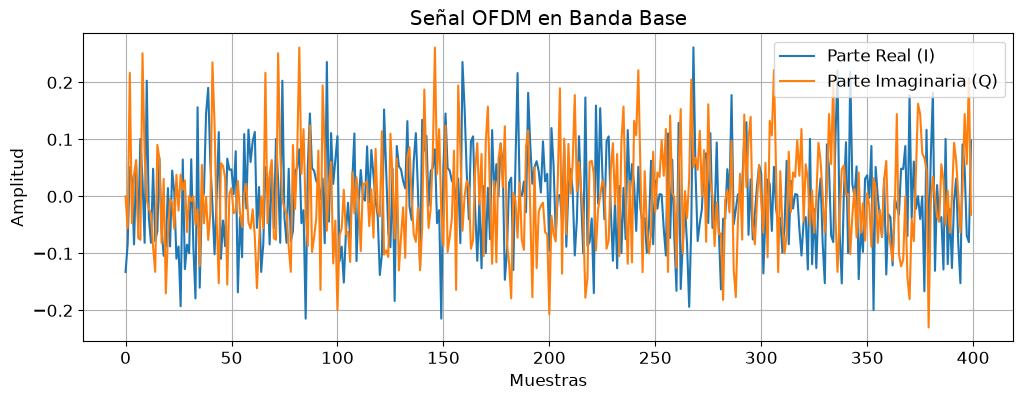

In [11]:
#Visualización de la señal transmitida
plt.figure(figsize=(12,4))

plt.plot(np.real(tx_signal[:400]), label="Parte Real (I)")
plt.plot(np.imag(tx_signal[:400]), label="Parte Imaginaria (Q)")

plt.title("Señal OFDM en Banda Base")
plt.xlabel("Muestras")
plt.ylabel("Amplitud")

plt.grid(True)
plt.legend()

plt.show()

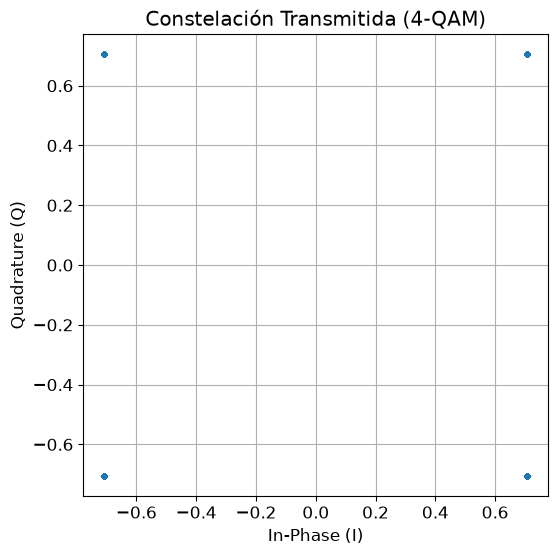

In [12]:
#Constelación transmitida
plt.figure(figsize=(6,6))

plt.scatter(symbols_tx.real,
            symbols_tx.imag,
            s=8)

plt.grid(True)

plt.xlabel("In-Phase (I)")
plt.ylabel("Quadrature (Q)")

plt.title(f"Constelación Transmitida ({M}-QAM)")

plt.axis("equal")

plt.show()

In [13]:
# ======================================================
# CANAL
# ======================================================

def ideal_channel(tx_signal):
    """
    Canal ideal.

    No modifica la señal.
    """

    return tx_signal.copy()

In [14]:
# ======================================================
# DFT (IMPLEMENTACIÓN DIRECTA)
# ======================================================

def dft(x):
    """
    Implementación directa de la DFT.

    Complejidad O(N²)

    Solo con fines educativos.
    """

    N = len(x)

    X = np.zeros(N, dtype=complex)

    for k in range(N):

        suma = 0

        for n in range(N):

            suma += x[n] * np.exp(-2j * np.pi * k * n / N)

        X[k] = suma

    return X

In [15]:
# ======================================================
# RECEPTOR OFDM
# ======================================================

def ofdm_receiver(rx_signal, N, CP):
    """
    Receptor OFDM.

    Etapas:

        Serie -> Paralelo
        Eliminar CP
        FFT
        Paralelo -> Serie
    """

    symbol_length = N + CP

    n_symbols = len(rx_signal) // symbol_length

    received_symbols = []

    for i in range(n_symbols):

        # ------------------------------------------
        # Extraer un símbolo OFDM
        # ------------------------------------------

        start = i * symbol_length
        end = start + symbol_length

        block = rx_signal[start:end]

        # ------------------------------------------
        # Eliminar prefijo cíclico
        # ------------------------------------------

        block = remove_cp(block, CP)

        # ------------------------------------------
        # Volver al dominio de la frecuencia
        # ------------------------------------------

        freq_signal = np.fft.fft(block)

        # --------------------------------------------------
        # Si se quisiera implementar mediante la DFT:
        #
        # freq_signal = dft(block)
        #
        # (Muchísimo más lenta que la FFT)
        # --------------------------------------------------

        received_symbols.extend(freq_signal)

    return np.array(received_symbols)

In [16]:
#Recepción
# ======================================================
# CANAL
# ======================================================

rx_signal = ideal_channel(tx_signal)

# ======================================================
# RECEPTOR OFDM
# ======================================================

symbols_rx = ofdm_receiver(rx_signal, N, CP)

print("Cantidad de símbolos recibidos:", len(symbols_rx))

Cantidad de símbolos recibidos: 32000


In [17]:
# ======================================================
# DEMODULACIÓN
# ======================================================

bits_rx = demodulator(symbols_rx, M)

print("Bits recibidos:", len(bits_rx))

Bits recibidos: 64000


In [18]:
# ======================================================
# BIT ERROR RATE
# ======================================================

bit_errors = np.sum(bits_tx != bits_rx)

ber = bit_errors / len(bits_tx)

print("="*40)
print("RESULTADOS")
print("="*40)

print(f"Bits transmitidos : {len(bits_tx)}")
print(f"Bits erróneos     : {bit_errors}")
print(f"BER               : {ber:.6e}")

RESULTADOS
Bits transmitidos : 64000
Bits erróneos     : 0
BER               : 0.000000e+00


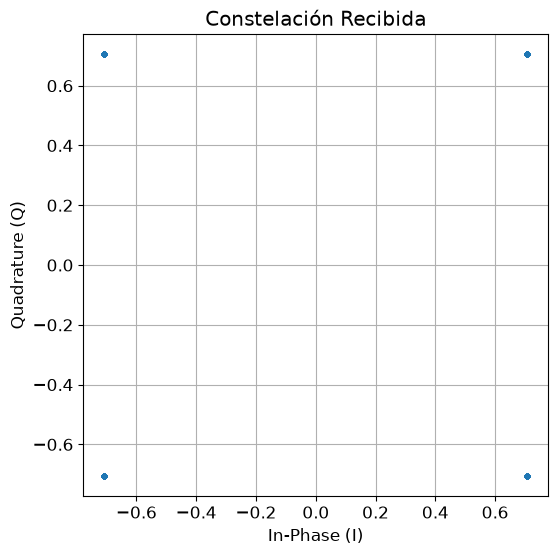

In [19]:
#Constelación recibida
plt.figure(figsize=(6,6))

plt.scatter(
    symbols_rx.real,
    symbols_rx.imag,
    s=8
)

plt.grid(True)

plt.xlabel("In-Phase (I)")
plt.ylabel("Quadrature (Q)")

plt.title("Constelación Recibida")

plt.axis("equal")

plt.show()